# Extra Module — Beyond RANS: LES, DES, and RSM

**Where this fits:** Module 3.2 (Turbulence Models) built a family of models — mixing-length, Spalart-Allmaras, $k$-$\varepsilon$, $k$-$\omega$ SST — that all share one assumption: the **Boussinesq eddy-viscosity hypothesis**. Turbulence is collapsed into a single number, $\nu_t$, that makes the time-averaged flow *behave as if* it had extra viscosity.

That assumption is remarkably good for attached, shear-dominated flows — which covers most of engineering CFD. But the Model Selection Guide at the end of that notebook flagged cases where it breaks down:

| Situation | Why Boussinesq fails | What replaces it |
|---|---|---|
| Unsteady separated flows (wakes, stalled wings, bluff bodies) | RANS time-averages away large, geometry-dependent vortices that are not statistically steady | **LES** / **DES** |
| Strong curvature, swirl, rotation | Turbulence becomes **anisotropic** — one stress component carries far more energy than the others | **RSM** |

This notebook is a conceptual tour of these three approaches: what changes physically, what new equations appear, and a small hands-on demo for each.

**Roadmap:**
1. The turbulence-modeling spectrum — DNS, LES, RANS: what's resolved vs. modeled, and the cost
2. LES — the energy cascade and the filtering operation
3. The Smagorinsky subgrid-scale model + a hands-on demo
4. DES — hybrid RANS/LES and the $d_{DES}$ switch
5. RSM — when Boussinesq fails, and the Reynolds-stress transport equation
6. Anisotropy demo — Boussinesq's prediction vs. real turbulence
7. Extended model selection guide

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The Turbulence-Modeling Spectrum

### Physical picture: how much do you compute, and how much do you guess?

Recall from Module 3.1: directly computing every eddy down to the Kolmogorov scale (**DNS** — Direct Numerical Simulation) costs roughly $Re^{9/4}$ grid points in 3D, and the time step shrinks too — total cost scales worse than $Re^3$. That's why RANS exists: replace **all** turbulence with $\nu_t$.

LES sits **between** these extremes — resolve the big, energy-containing eddies directly (they're geometry-dependent and hard to model anyway), and model only the small, "universal" eddies.

| Approach | What's *computed* | What's *modeled* | Relative cost vs RANS | Typical use |
|---|---|---|---|---|
| **DNS** | every scale, down to $\eta$ (Kolmogorov) | nothing | $10^6$–$10^9$+ | Research, low-$Re$ canonical flows |
| **LES** | large, energy-containing eddies | small, near-isotropic eddies (subgrid) | $10$–$100\times$ | Acoustics, mixing, unsteady wakes |
| **DES / hybrid** | large eddies away from walls; mean flow in attached BLs | subgrid (LES region) + all turbulence (RANS region) | $2$–$20\times$ | External aero with large separation |
| **RANS** ($k$-$\varepsilon$, SST, SA) | mean flow only | **all** turbulence, isotropically ($\nu_t$) | $1\times$ (baseline) | Design iteration, attached flows |
| **RANS** (RSM) | mean flow only | all turbulence, **anisotropically** (6 transport eqs) | $1$–$3\times$ | Swirl, curvature, anisotropic flows |

### Where the cutoff sits on the energy spectrum

```
log E(k)
   |
   |   \
   |     \___  <- large eddies: anisotropic, carry most of the
   |         \\    kinetic energy, geometry-dependent
   |           \\___
   |  RANS         \\___  <- inertial range: energy cascades down,
   |  models            \\\\\    nearly universal statistics (Kolmogorov -5/3)
   |  ALL of                 \\\___
   |  this!                       \\\___ <- dissipation range: viscosity wins
   |                                    \\\___
   +---------------------------------------------> log k
              ^                    ^
         LES resolves          LES models
         this (large scales)   this (subgrid)
```

A coarser LES mesh (larger filter width $\Delta$) moves the resolved/modeled split **to the left** — more is modeled, less is resolved. RANS is the extreme case: the split is pushed all the way to $k=0$, so **everything** is modeled. This single idea — *"where do I draw the line, and what do I do on each side of it?"* — is the thread connecting every model in this notebook.

## 2. Large Eddy Simulation — Resolve the Big, Model the Small

### Richardson's cascade

> "Big whirls have little whirls that feed on their velocity;
> little whirls have lesser whirls, and so on to viscosity." — L. F. Richardson, 1922

Energy enters the flow at the **largest scales** (set by the geometry — the width of a wake, the gap of a cavity). Through nonlinear interactions, big eddies break into smaller ones, transferring energy down the scales with almost no loss (the **inertial range** — this is where Kolmogorov's $-5/3$ spectrum slope comes from). Eventually eddies become so small that viscosity dominates and the energy is converted to heat (the **dissipation range**, at the Kolmogorov scale $\eta$).

### Why split the spectrum here?

| | Large eddies | Small eddies |
|---|---|---|
| Behavior | Anisotropic, geometry-dependent | Nearly isotropic, "universal" statistics |
| Easy to... | **compute** directly (low frequency $\to$ affordable $\Delta t$) | **model** with a simple formula (same physics everywhere) |
| Hard to... | model with one universal formula | resolve directly (need tiny $\Delta x,\Delta t$) |

LES exploits this: compute the part that's easy to compute, model the part that's easy to model.

### The filtering operation

Split velocity into a **resolved** (filtered) part and a **residual** (subgrid) part:

$$u = \bar{u} + u''$$

This looks exactly like the Reynolds decomposition $u=\bar u + u'$ from Module 3.1 — same *mathematical* operation (split + substitute into Navier-Stokes) — but a completely different *meaning*:

| | Reynolds decomposition (RANS) | Filtering (LES) |
|---|---|---|
| $\bar u$ represents | the full **time-average** | everything **larger than $\Delta$** |
| $u'$ / $u''$ represents | **all** turbulent fluctuations | only the **subgrid** (small-scale) motion |
| Depends on the mesh? | No — $\bar u$ is a flow property | **Yes** — $\Delta \approx$ local grid spacing |

Substituting $u=\bar u + u''$ into Navier-Stokes and filtering produces the same kind of new, unclosed term as before — the **subgrid-scale (SGS) stress**:

$$\tau_{ij} = \overline{u_iu_j} - \bar u_i\bar u_j$$

This is the LES analogue of the Reynolds stress $-\rho\overline{u_i'u_j'}$ — and it needs a closure model, just like $\nu_t$ did for RANS.

## 3. The Smagorinsky Model — Eddy Viscosity for the Small Scales

The simplest closure for $\tau_{ij}$ reuses the Boussinesq idea — but applies it **only to the subgrid stresses**:

$$\tau_{ij} - \frac{1}{3}\tau_{kk}\delta_{ij} = -2\nu_{sgs}\bar S_{ij}$$

$$\boxed{\nu_{sgs} = (C_s\Delta)^2|\bar S|}, \qquad |\bar S| = \sqrt{2\bar S_{ij}\bar S_{ij}}$$

- $\Delta$ — the **filter width**, taken equal to the local grid spacing (often $\Delta=(\Delta x\Delta y\Delta z)^{1/3}$)
- $C_s\approx 0.17$ — the Smagorinsky constant, calibrated from isotropic turbulence (just like $C_\mu=0.09$ was for $k$-$\varepsilon$)
- $\bar S_{ij}$ — the **resolved** strain rate (computed from $\bar u$, the part you actually solve for)

### The crucial difference from RANS

| | RANS $\nu_t$ | LES $\nu_{sgs}$ |
|---|---|---|
| Models | **all** of turbulence | only what's **below grid scale** |
| Formula | $C_\mu k^2/\varepsilon$ (flow property) | $(C_s\Delta)^2|\bar S|$ (flow **and mesh**) |
| Refine the mesh $\to$ | $\nu_t$ unchanged (same physics) | $\nu_{sgs}\to0$ as $\Delta\to0$ |
| Limit $\Delta\to0$ | still models everything | becomes **DNS** — nothing left to model |

This mesh-dependence is the single most important conceptual difference in this notebook: **in RANS, refining the mesh gives you a more accurate solution to the *same* model. In LES, refining the mesh changes the model itself** — you are resolving more physics and modeling less.

The demo below builds a "turbulent-like" 1D signal, filters it, and checks: does $\nu_{sgs}\to0$ as $\Delta\to0$, the way the theory promises?

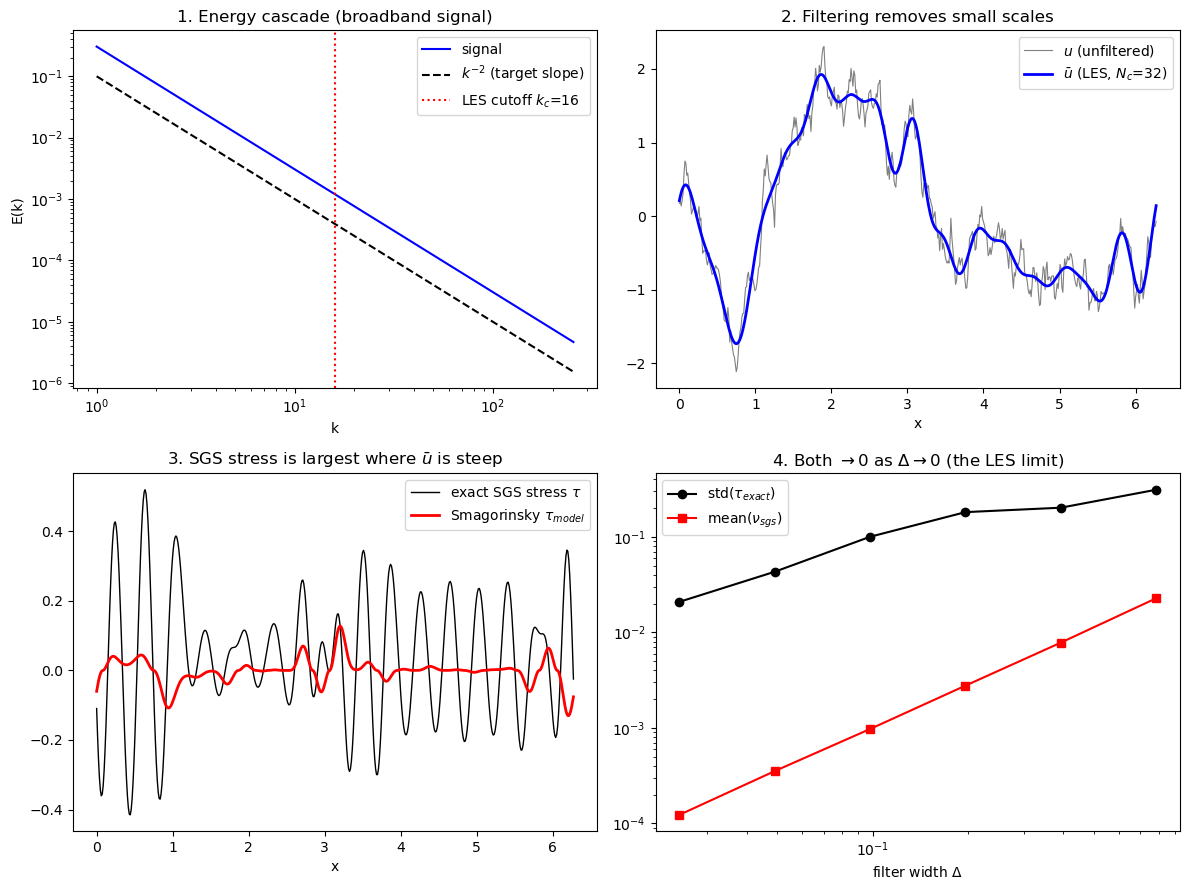

At N_c=32: Delta=0.1963, std(tau_exact)=0.1812, mean(nu_sgs)=0.00277

As resolution increases from N_c=8 to 256:
  std(tau_exact):  0.3108  ->  0.0208
  mean(nu_sgs):    0.02273  ->  0.00012


In [2]:
# ── LES demo: filtering, SGS stress, and the Delta->0 limit ─────────────────
# We build a broadband 1D "turbulent-like" signal with an energy cascade
# E(k) ~ k^-2 (random phases, amplitude ~ 1/k -- same idea as the Burgers
# spectrum from Module 1.8: steep gradients create a broad range of scales).

N  = 512                 # "DNS" resolution
L  = 2*np.pi
x  = np.linspace(0, L, N, endpoint=False)
k  = np.fft.fftfreq(N, d=L/N) * 2*np.pi

rng = np.random.default_rng(0)
u_hat = np.zeros(N, dtype=complex)
for kk in range(1, N//2):
    amp   = kk**(-1.0)                 # amplitude ~ 1/k  ->  E(k) ~ k^-2
    phase = rng.uniform(0, 2*np.pi)
    u_hat[kk]  = amp*np.exp(1j*phase)
    u_hat[-kk] = np.conj(u_hat[kk])    # keep u(x) real

u_dns = np.real(np.fft.ifft(u_hat)) * N
u_dns /= np.std(u_dns)
u_hat  = np.fft.fft(u_dns)

Cs = 0.17

def les_filter(N_c):
    # apply a sharp spectral cutoff at the LES grid resolution N_c
    k_c  = N_c // 2
    mask = np.abs(k) <= k_c
    ubar_hat = u_hat * mask
    ubar     = np.real(np.fft.ifft(ubar_hat))
    uu_bar   = np.real(np.fft.ifft(np.fft.fft(u_dns**2) * mask))
    tau      = uu_bar - ubar**2                        # exact SGS stress
    Delta    = L / N_c
    dubar_dx = np.real(np.fft.ifft(1j*k*ubar_hat))
    nu_sgs   = (Cs*Delta)**2 * np.abs(dubar_dx)         # Smagorinsky
    tau_model = -2*nu_sgs*dubar_dx
    return ubar, tau, nu_sgs, tau_model, Delta

# ── Pick one LES resolution to inspect in detail ─────────────────────────────
N_c = 32
ubar, tau, nu_sgs, tau_model, Delta = les_filter(N_c)

# ── Sweep resolutions to check the Delta->0 limit ────────────────────────────
Ncs = np.array([8, 16, 32, 64, 128, 256])
Deltas, std_tau, mean_nusgs = [], [], []
for Nci in Ncs:
    _, tau_i, nu_i, _, Delta_i = les_filter(Nci)
    Deltas.append(Delta_i)
    std_tau.append(np.std(tau_i))
    mean_nusgs.append(np.mean(nu_i))

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

E  = np.abs(u_hat[1:N//2])**2 / N**2
kp = k[1:N//2]
axes[0,0].loglog(kp, E, 'b-', label='signal')
axes[0,0].loglog(kp, 0.1*kp**(-2.0), 'k--', label=r'$k^{-2}$ (target slope)')
axes[0,0].axvline(N_c/2, color='r', ls=':', label=fr'LES cutoff $k_c$={N_c//2}')
axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('E(k)')
axes[0,0].set_title('1. Energy cascade (broadband signal)')
axes[0,0].legend()

axes[0,1].plot(x, u_dns, color='gray', lw=0.8, label=r'$u$ (unfiltered)')
axes[0,1].plot(x, ubar, 'b-', lw=2, label=fr'$\bar u$ (LES, $N_c$={N_c})')
axes[0,1].set_xlabel('x')
axes[0,1].set_title('2. Filtering removes small scales')
axes[0,1].legend()

axes[1,0].plot(x, tau, 'k-', lw=1, label=r'exact SGS stress $\tau$')
axes[1,0].plot(x, tau_model, 'r-', lw=2, label=r'Smagorinsky $\tau_{model}$')
axes[1,0].set_xlabel('x')
axes[1,0].set_title(r'3. SGS stress is largest where $\bar u$ is steep')
axes[1,0].legend()

axes[1,1].loglog(Deltas, std_tau, 'ko-', label=r'std($\tau_{exact}$)')
axes[1,1].loglog(Deltas, mean_nusgs, 'rs-', label=r'mean($\nu_{sgs}$)')
axes[1,1].set_xlabel(r'filter width $\Delta$')
axes[1,1].set_title(r'4. Both $\to 0$ as $\Delta\to 0$ (the LES limit)')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print(f'At N_c={N_c}: Delta={Delta:.4f}, std(tau_exact)={np.std(tau):.4f}, '
      f'mean(nu_sgs)={np.mean(nu_sgs):.5f}')
print(f'\nAs resolution increases from N_c={Ncs[0]} to {Ncs[-1]}:')
print(f'  std(tau_exact):  {std_tau[0]:.4f}  ->  {std_tau[-1]:.4f}')
print(f'  mean(nu_sgs):    {mean_nusgs[0]:.5f}  ->  {mean_nusgs[-1]:.5f}')

### Reading the four panels

1. **Energy cascade** — the signal's spectrum follows $E(k)\sim k^{-2}$ across a wide range of $k$ (broadband — energy at every scale, like real turbulence). The red line marks the LES cutoff $k_c$: everything to its right is what LES *throws away* and must model.
2. **Filtering** — $\bar u$ (blue) is a smoothed version of $u$ (gray): all the wiggles smaller than $\Delta$ are gone. This is exactly what an LES solution looks like — smooth, but not exactly the true field.
3. **SGS stress** — $\tau$ (black) is concentrated where $\bar u$ has its steepest gradients — physically, this is where the "missing" small-scale motion would have been most active. The Smagorinsky model $\tau_{model}$ (red) is much smaller and smoother — it gets the *general location* right but is famously inaccurate *pointwise* (a well-known result for Smagorinsky — see panel 4 for why it still works).
4. **The $\Delta\to0$ limit** — this is the panel that matters most. As the LES resolution increases (smaller $\Delta$), **both** the true SGS stress and the modeled $\nu_{sgs}$ shrink toward zero. Smagorinsky doesn't need to be pointwise-accurate (it isn't!) — it only needs to remove **roughly the right amount of energy on average**, and vanish in the DNS limit. That's a much easier target than getting $\tau_{ij}(x,t)$ exactly right everywhere.

> **Common misconception:** "LES is just RANS with a smaller $\nu_t$." It's not — $\nu_t$ (RANS) is a property of the *flow*; $\nu_{sgs}$ (LES) is a property of the *flow and the mesh together*, and it is explicitly designed to disappear as the mesh improves.

## 4. DES — Hybrid RANS/LES

### The cost argument

A full LES of an aircraft wing at cruise Reynolds number would need to resolve the boundary layer down to near-DNS resolution over the **entire wetted surface** — computationally hopeless. But the boundary layer itself is exactly where RANS (SA, SST) works *well*: thin, attached, shear-dominated. The **wake** behind a stalled wing or a bluff body, on the other hand, is full of large, unsteady, geometry-scale eddies — exactly what RANS smears out and LES is good at.

**DES (Detached Eddy Simulation, Spalart et al. 1997)**: run RANS in attached boundary layers, switch to LES in regions of massive separation — using a **single set of equations** that smoothly blends between the two.

### The switch: SA-DES

Recall the Spalart-Allmaras destruction term from Module 3.2:

$$c_{w1}f_w\left(\frac{\tilde\nu}{d}\right)^2, \qquad d=\text{distance to the nearest wall}$$

DES replaces $d$ with:

$$\boxed{d_{DES}=\min(d,\;C_{DES}\Delta)}, \qquad C_{DES}\approx 0.65$$

where $\Delta$ is the local **grid spacing** (largest cell dimension).

- **Where the mesh is fine relative to $d$** ($d<C_{DES}\Delta$): $d_{DES}=d$ $\to$ unchanged SA $\to$ **RANS mode**
- **Where the mesh is coarse relative to $d$** ($d>C_{DES}\Delta$): $d_{DES}=C_{DES}\Delta$ $\to$ destruction term grows $\to$ $\tilde\nu$ (and $\nu_t$) **drops** $\to$ the model gets out of the way and lets the *grid* resolve the large eddies $\to$ **LES mode**

### The catch: grid-induced separation (GIS)

The switch only compares $d$ to $\Delta$ — it has **no idea** whether you *meant* to be in a boundary layer. If your mesh is wall-resolved (tiny $\Delta$ near the wall, needed for $y^+\approx1$), then $C_{DES}\Delta$ can become smaller than $d$ **immediately off the wall**, switching to LES mode *inside the boundary layer* — where the wall-parallel spacing is nowhere near fine enough to actually resolve anything. The model's eddy viscosity drops, but the grid can't replace it $\to$ too little total stress $\to$ the boundary layer separates early. This is **grid-induced separation**, and it was DES's biggest practical problem.

**DDES (Delayed DES, Spalart et al. 2006)** fixes this with a *shielding function* $f_d$ (built from the SA model's own blending function) that forces $d_{DES}=d$ throughout the boundary layer **regardless of $\Delta$**, only allowing the LES switch once the flow has genuinely separated.

The demo below reproduces the GIS effect directly from the $d_{DES}$ formula.

coarse mesh ($\Delta=0.05$ everywhere)     RANS region: y/H < 0.0326
wall-resolved mesh ($\Delta$: 0.001$\to$0.05) RANS region: y/H < 0.0011


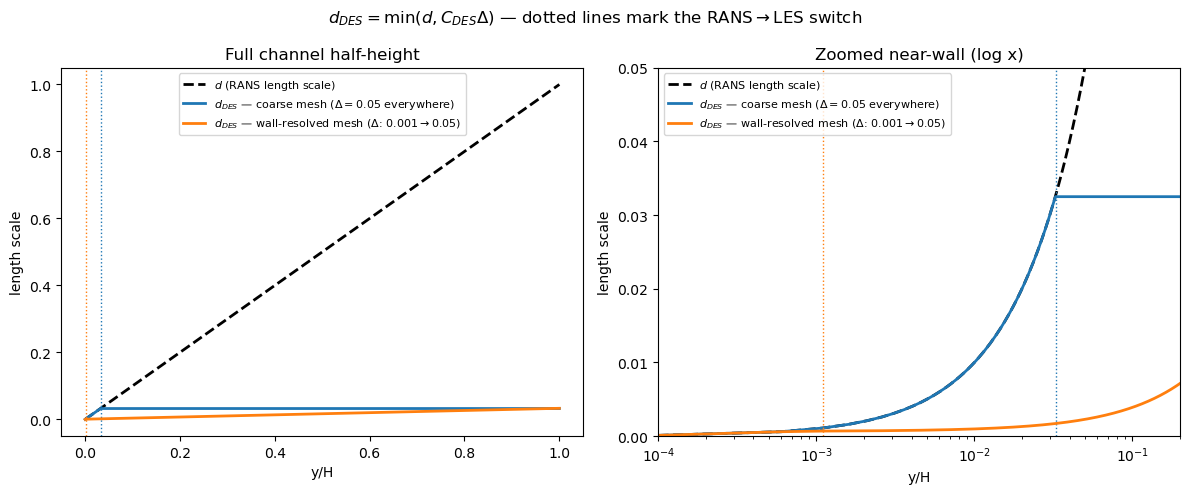

In [3]:
# ── DES demo: where does d_DES switch from RANS to LES mode? ────────────────
H = 1.0
y = np.linspace(1e-4, H, 2000)     # distance from wall
C_DES = 0.65

Delta_A = 0.05*np.ones_like(y)            # coarse mesh everywhere
Delta_B = 0.001 + 0.05*(y/H)              # wall-resolved -> same coarse Delta in the core

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, xscale in [(ax1, 'linear'), (ax2, 'log')]:
    ax.plot(y/H, y, 'k--', lw=2, label=r'$d$ (RANS length scale)')
    for Delta, label, color in [
            (Delta_A, r'coarse mesh ($\Delta=0.05$ everywhere)', 'C0'),
            (Delta_B, r'wall-resolved mesh ($\Delta$: 0.001$\to$0.05)', 'C1')]:
        d_des = np.minimum(y, C_DES*Delta)
        ax.plot(y/H, d_des, color=color, lw=2, label=fr'$d_{{DES}}$ — {label}')
        switch = y[d_des < y][0] / H
        ax.axvline(switch, color=color, ls=':', lw=1)
        if xscale == 'log':
            print(f'{label:42s} RANS region: y/H < {switch:.4f}')
    ax.set_xscale(xscale)
    ax.set_xlabel('y/H'); ax.set_ylabel('length scale')
    ax.legend(fontsize=8)

ax1.set_title('Full channel half-height')
ax2.set_xlim(1e-4, 0.2); ax2.set_ylim(0, 0.05)
ax2.set_title('Zoomed near-wall (log x)')
plt.suptitle(r'$d_{DES}=\min(d, C_{DES}\Delta)$ — dotted lines mark the RANS$\to$LES switch')
plt.tight_layout()
plt.show()

### Reading the plot

- **Coarse mesh everywhere** ($\Delta=0.05$, blue): RANS mode holds out to $y/H\approx0.033$ — about 3% of the channel half-height. A believable "thin attached boundary layer."
- **Wall-resolved mesh** ($\Delta$ growing from $0.001$ to $0.05$, orange): RANS mode survives only to $y/H\approx0.001$ — over **30x smaller**. The very mesh refinement you added *to capture the boundary layer accurately* is what destroys DES's ability to treat it as a boundary layer!

This is GIS in a nutshell: $d_{DES}$ only knows about $d$ and $\Delta$ — it cannot tell "thin mesh because I'm resolving a thin boundary layer" from "thin mesh because this is genuinely a small-eddy region." DDES adds exactly that missing information (via $f_d$, which is large only where the SA model is "confident" it's in an attached boundary layer).

**Takeaway:** the RANS/LES split in DES is not a property of the *flow* (like the energy spectrum in §1) — it's an emergent property of the **flow + mesh + model formula together**, and can behave counter-intuitively. Always use DDES (or IDDES), never plain DES, in practice.

## 5. Reynolds Stress Model — When Boussinesq Fails

### What Boussinesq actually assumes

$$-\overline{u_i'u_j'} = 2\nu_tS_{ij} - \frac{2}{3}k\delta_{ij}$$

Look at the **diagonal** ($i=j$) terms for an incompressible flow ($S_{kk}=0$): every normal stress reduces to

$$\overline{u_i'u_i'} = \frac{2}{3}k \quad\text{(no sum)} \qquad\Longrightarrow\qquad \overline{u'u'}=\overline{v'v'}=\overline{w'w'}=\frac{2}{3}k$$

**Boussinesq predicts perfectly isotropic normal stresses — by construction — no matter what the flow is doing.** $k$-$\varepsilon$, $k$-$\omega$ SST, SA: all of them inherit this, because they all close the stress tensor through a single scalar $\nu_t$.

### The exact (unmodeled) alternative: solve for $\overline{u_i'u_j'}$ directly

RSM solves a transport equation for **each of the 6 independent components** of $\overline{u_i'u_j'}$:

$$\frac{D\overline{u_i'u_j'}}{Dt} = \underbrace{P_{ij}}_{\text{production}} - \underbrace{\varepsilon_{ij}}_{\text{dissipation}} + \underbrace{\Pi_{ij}}_{\text{pressure-strain}} + \text{diffusion}$$

- **$P_{ij}=-\overline{u_i'u_k'}\dfrac{\partial U_j}{\partial x_k}-\overline{u_j'u_k'}\dfrac{\partial U_i}{\partial x_k}$** — this is **exact**, no modeling needed! It's written entirely in terms of the stresses themselves and the *mean* velocity gradient.
- **$\varepsilon_{ij}$** — dissipation, often modeled as isotropic: $\frac{2}{3}\varepsilon\delta_{ij}$ (small scales ARE isotropic — same argument as LES's subgrid scales!)
- **$\Pi_{ij}$** — **pressure-strain / redistribution**. Crucially, $\Pi_{kk}=0$ — it moves energy *between* components without changing total $k$. This is the "return to isotropy" term.

### Why production alone explains the anisotropy

For simple shear ($\partial U/\partial y$ only, all else zero), expand $P_{ij}$:

$$P_{11}=-2\overline{u'v'}\frac{\partial U}{\partial y}, \qquad P_{22}=P_{33}=0$$

**Production feeds $\overline{u'u'}$ directly and *only* $\overline{u'u'}$.** The wall-normal and spanwise stresses ($\overline{v'v'}$, $\overline{w'w'}$) only grow through $\Pi_{ij}$ — redistribution *from* $\overline{u'u'}$, which is slower and incomplete. This is the exact mechanism behind "wall kills $v'$" from Module 3.1: production is one-directional, and redistribution never fully equalizes it.

### When curvature/rotation enters

In a curved shear layer, an extra term appears in $P_{12}$ proportional to the streamline curvature $U/R$ (radius $R$). Boussinesq's $\nu_tS_{ij}$ depends only on the *local* mean strain rate — it has **no way to know about $R$**. RSM's production term, being exact, picks this up automatically. This is why curved ducts, swirling combustors, and rotating machinery need RSM (or at least a curvature correction) — Boussinesq is missing physics, not just inaccurate.

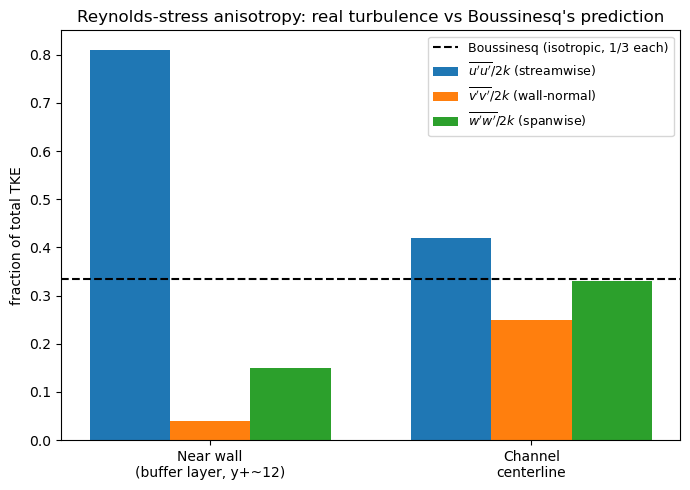

Near wall: u'u'/2k = 0.81 -- about 2.4x the isotropic value
Centerline is closer to isotropic, but still not exactly 1/3 each.


In [4]:
# ── Anisotropy demo: Boussinesq's isotropic prediction vs real turbulence ───
# Representative normalized Reynolds stresses (fractions of 2k = sum of all
# three normal stresses) at two locations in a turbulent channel:
locations = ['Near wall\n(buffer layer, y+~12)', 'Channel\ncenterline']
uu = np.array([0.81, 0.42])   # <u'u'>/2k  (streamwise)
vv = np.array([0.04, 0.25])   # <v'v'>/2k  (wall-normal)
ww = np.array([0.15, 0.33])   # <w'w'>/2k  (spanwise)

assert np.allclose(uu+vv+ww, 1.0), "must sum to 1 -- redistribution conserves k"

x = np.arange(len(locations))
width = 0.25

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x-width, uu, width, label=r"$\overline{u'u'}/2k$ (streamwise)")
ax.bar(x,        vv, width, label=r"$\overline{v'v'}/2k$ (wall-normal)")
ax.bar(x+width,  ww, width, label=r"$\overline{w'w'}/2k$ (spanwise)")
ax.axhline(1/3, color='k', ls='--', label='Boussinesq (isotropic, 1/3 each)')

ax.set_xticks(x); ax.set_xticklabels(locations)
ax.set_ylabel('fraction of total TKE')
ax.set_title("Reynolds-stress anisotropy: real turbulence vs Boussinesq's prediction")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Near wall: u'u'/2k = {uu[0]:.2f} -- about {uu[0]/(1/3):.1f}x the isotropic value")
print('Centerline is closer to isotropic, but still not exactly 1/3 each.')

### Reading the plot

- **Near the wall**, the streamwise component $\overline{u'u'}$ holds about **81%** of the turbulent kinetic energy — versus the 33% Boussinesq insists on for *every* flow. The wall-normal component $\overline{v'v'}$ is almost shut off (4%), exactly matching "wall kills $v'$" from Module 3.1.
- **At the centerline**, turbulence is closer to (but still not exactly) isotropic — far from any wall, production is weaker and redistribution has more time to act.
- **The bars always sum to 1** at both locations — because $\Pi_{kk}=0$: redistribution moves energy *between* components, it never creates or destroys $k$.

Any eddy-viscosity model — mixing-length, SA, $k$-$\varepsilon$, $k$-$\omega$ SST — would draw the dashed line (1/3, 1/3, 1/3) at **every point in the domain**, regardless of these numbers. For flows where the *shape* of the stress tensor matters (secondary flows in ducts, swirl, curved blades), that's not a small error — it's a different prediction of the physics.

## 6. Extended Model Selection Guide

| Model | Equations | Resolves | Closure | Mesh-dependent closure? | Cost vs RANS | Best for |
|---|---|---|---|---|---|---|
| Mixing-length | 0 | mean flow | $\ell_m^2|d\bar u/dy|$ | No | $1\times$ | Teaching, simple shear |
| Spalart-Allmaras | 1 | mean flow | $\tilde\nu f_{v1}$ | No | $1\times$ | Attached aero BLs |
| $k$-$\varepsilon$ / $k$-$\omega$ SST | 2 | mean flow | $C_\mu k^2/\varepsilon$ (blended) | No | $1\times$ | General-purpose, design |
| **RSM** | 7 (6 stresses + $\varepsilon$) | mean flow | exact production, modeled $\Pi_{ij},\varepsilon_{ij}$ | No | $1$–$3\times$ | Swirl, curvature, anisotropy |
| **LES** | 3–4 (filtered N-S + SGS) | large eddies (3D, unsteady) | $\nu_{sgs}=(C_s\Delta)^2|\bar S|$ | **Yes** — $\to0$ as $\Delta\to0$ | $10$–$100\times$ | Unsteady separation, acoustics, mixing |
| **DES / DDES** | SA or SST + $d_{DES}$ switch | large eddies away from walls; mean flow in BLs | RANS closure + Smagorinsky-like in LES region | **Yes**, in LES region | $2$–$20\times$ | Massively separated external aero |

### The one-sentence version of this whole notebook

> **RANS** asks "what is turbulence doing, on average, *everywhere*?" and answers with one number ($\nu_t$).
> **LES** asks "which eddies can my mesh see?" and computes those directly, modeling only the rest.
> **DES** asks both questions at once, in different parts of the domain.
> **RSM** keeps asking the RANS question, but refuses to assume the answer looks the same in every direction.

---
**Next:** back to Module 3.21 — Multigrid Methods.

## Exercise

**Predict first, then verify.**

1. **LES demo (panel 4):** Change `Cs` from `0.17` to `0.05` and re-run. Predict first: will `mean(nu_sgs)` increase or decrease at each resolution? Will the *slope* of the convergence-to-zero change, or just the overall level? Verify.

2. **LES demo (panel 1):** Change the IC exponent from `kk**(-1.0)` to `kk**(-0.5)` (shallower spectrum — more energy at small scales). Predict: does the LES cutoff now throw away a *larger* or *smaller* fraction of the total energy? Compute `KE_sgs / KE_total` for `N_c=32` to check.

3. **DES demo:** Add a third mesh, `Delta_C = 0.01*np.ones_like(y)` (uniformly fine — finer than `Delta_A`, but still uniform like it). Predict: is its RANS region larger or smaller than `Delta_A`'s? What does this tell you about whether "finer mesh = more RANS protection" is generally true?

4. **RSM demo:** Using the near-wall values, suppose $\overline{u'u'}^+=8.0$ (i.e. $\overline{u'u'}/u_\tau^2=8.0$). Use the fractions given to compute $2k^+$, then $\overline{v'v'}^+$ and $\overline{w'w'}^+$. Compare your $k^+$ to the wall-function value $k_w^+=1/\sqrt{C_\mu}$ from Module 3.2 — are they roughly the same order of magnitude, even though the *split* between components is completely different from what Boussinesq assumes?

5. **Conceptual:** A colleague says "I'll just run $k$-$\omega$ SST on a very fine mesh instead of LES — more resolution is always better." Using the "mesh-dependent closure" column from the summary table, explain why refining a RANS mesh does **not** make the result converge toward an LES (or DNS) result, no matter how fine the mesh gets.